# Lehrevaluation Analyse

Auswertung der Lehrevaluationen (evasys) pro Dozent:
- **Ratings** (LR01–LR07) im Zeitverlauf
- **Freitext-Feedback** zusammengefasst

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (12, 6)
matplotlib.rcParams['font.size'] = 11

# Daten laden
df = pd.read_csv('../output/evaluations.csv')
df_text = pd.read_csv('../output/free_text.csv')

# Semester chronologisch sortieren
semester_order = ['WiSe2023', 'SoSe2024', 'WiSe2024', 'SoSe2025', 'WiSe2025']
df['semester'] = pd.Categorical(df['semester'], categories=semester_order, ordered=True)
df = df.sort_values('semester')

print(f'{len(df)} Evaluationen, {df.lecturer_name.nunique()} Dozenten, {df.semester.nunique()} Semester')

160 Evaluationen, 73 Dozenten, 5 Semester


## Übersicht: Evaluationen pro Dozent

In [10]:
# Anzahl Evaluationen pro Dozent pro Semester
overview = df.pivot_table(
    index='lecturer_name', columns='semester',
    values='lr07', aggfunc='count', fill_value=0,
    observed=True
)
overview['Gesamt'] = overview.sum(axis=1)
overview = overview.sort_values('Gesamt', ascending=False)
overview

semester,WiSe2023,SoSe2024,WiSe2024,SoSe2025,WiSe2025,Gesamt
lecturer_name,,,,,,
"Radde, Jens",2,0,3,3,1,9
"Woogt, Sven",1,1,2,1,3,8
"Buehner, Rene",2,1,2,0,3,8
"Sivuek, Said",2,1,2,0,2,7
"Voshage, Ramona",0,0,3,0,3,6
...,...,...,...,...,...,...
"Primsch, Marius",0,1,0,0,0,1
"Resch, Olaf",0,0,0,0,1,1
"Kaltschew, Kristian",0,1,0,0,0,1


## Rating-Trends pro Dozent

LR01–LR07 Globalwerte (Mittelwerte, Skala 1–6) über die Semester.

In [11]:
LR_COLS = {
    'lr01': 'LR01: Lernziele klar definiert',
    'lr02': 'LR02: Gut strukturiert',
    'lr03': 'LR03: Fachliche Kompetenz',
    'lr04': 'LR04: Engagement',
    'lr05': 'LR05: Interessant gestaltet',
    'lr06': 'LR06: Motiviert zur Beteiligung',
    'lr07': 'LR07: Gesamtbewertung',
}


def plot_lecturer_trends(lecturer_name, questions=None):
    """LR-Trends über Semester für einen Dozenten."""
    if questions is None:
        questions = LR_COLS

    data = df[df['lecturer_name'] == lecturer_name].copy()
    if data.empty:
        print(f'Keine Daten für {lecturer_name}')
        return

    fig, axes = plt.subplots(len(questions), 1, figsize=(10, 2.5 * len(questions)), sharex=True)
    if len(questions) == 1:
        axes = [axes]

    for ax, (col, label) in zip(axes, questions.items()):
        # Einzelne Datenpunkte (pro Kurs)
        valid = data.dropna(subset=[col])
        for _, row in valid.iterrows():
            ax.scatter(str(row['semester']), row[col], alpha=0.5, color='steelblue', s=40, zorder=3)

        # Mittelwert-Linie pro Semester
        means = valid.groupby('semester', observed=True)[col].mean()
        ax.plot([str(s) for s in means.index], means.values, 'o-', color='darkblue', linewidth=2, markersize=7, zorder=4)

        ax.set_ylim(1, 6.2)
        ax.set_ylabel('Bewertung')
        ax.set_title(label, fontsize=10)
        ax.grid(True, alpha=0.3)

        overall_mean = valid[col].mean()
        ax.axhline(y=overall_mean, color='red', linestyle='--', alpha=0.4)
        ax.text(0.99, overall_mean, f' {overall_mean:.1f}', transform=ax.get_yaxis_transform(),
                va='center', ha='left', color='red', fontsize=8)

    fig.suptitle(f'Evaluationstrends: {lecturer_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [12]:
def plot_lecturer_profile(lecturer_name):
    """Alle 7 LR-Werte als Profil-Vergleich nach Semester."""
    data = df[df['lecturer_name'] == lecturer_name]
    lr_cols = [f'lr0{i}' for i in range(1, 8)]
    lr_labels = ['Lernziele', 'Struktur', 'Kompetenz', 'Engagement', 'Interessant', 'Motivation', 'Gesamt']

    means = data.groupby('semester', observed=True)[lr_cols].mean()

    fig, ax = plt.subplots(figsize=(10, 5))
    x = range(len(lr_labels))
    colors = plt.cm.viridis_r([i / max(1, len(means) - 1) for i in range(len(means))])

    for i, semester in enumerate(means.index):
        values = means.loc[semester].values
        ax.plot(x, values, 'o-', label=str(semester), linewidth=2, markersize=8, color=colors[i])

    ax.set_xticks(x)
    ax.set_xticklabels(lr_labels, rotation=45, ha='right')
    ax.set_ylabel('Mittelwert (1–6)')
    ax.set_ylim(1, 6.2)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_title(f'LR-Profil nach Semester: {lecturer_name}')
    plt.tight_layout()
    plt.show()

### Dozent auswählen und Trends anzeigen

In [13]:
# Dozenten mit Anzahl Evaluationen
lecturer_stats = df.groupby('lecturer_name').agg(
    Evaluationen=('lr07', 'count'),
    Semester=('semester', 'nunique'),
    LR07_Mittel=('lr07', 'mean')
).sort_values('Evaluationen', ascending=False)
lecturer_stats['LR07_Mittel'] = lecturer_stats['LR07_Mittel'].round(2)
lecturer_stats.head(20)

,Evaluationen,Semester,LR07_Mittel
lecturer_name,,,
"Radde, Jens",9,4,5.02
"Woogt, Sven",8,5,5.64
"Buehner, Rene",8,4,5.60
"Sivuek, Said",7,4,5.66
"Voshage, Ramona",6,2,5.17
"Wolz, Peter",4,3,3.30
"Afflerbach, Thomas",3,3,5.30
"Mertens, Antje",3,2,5.53
"Paarz, Michael",3,3,5.77


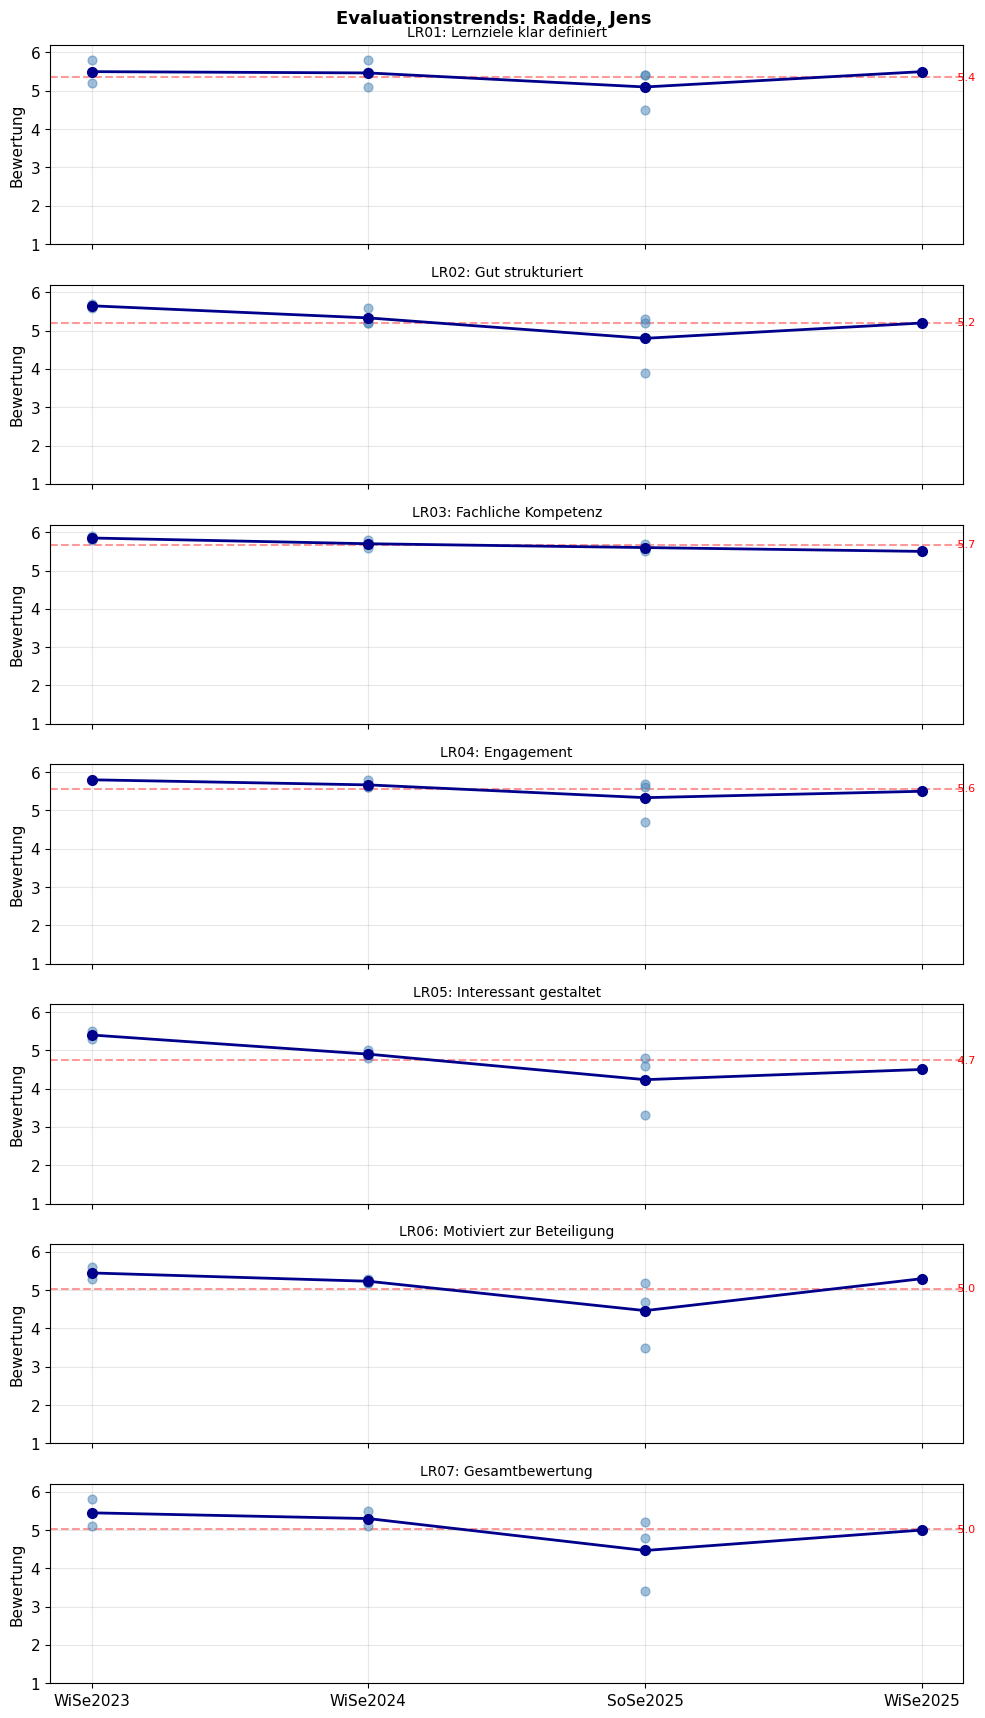

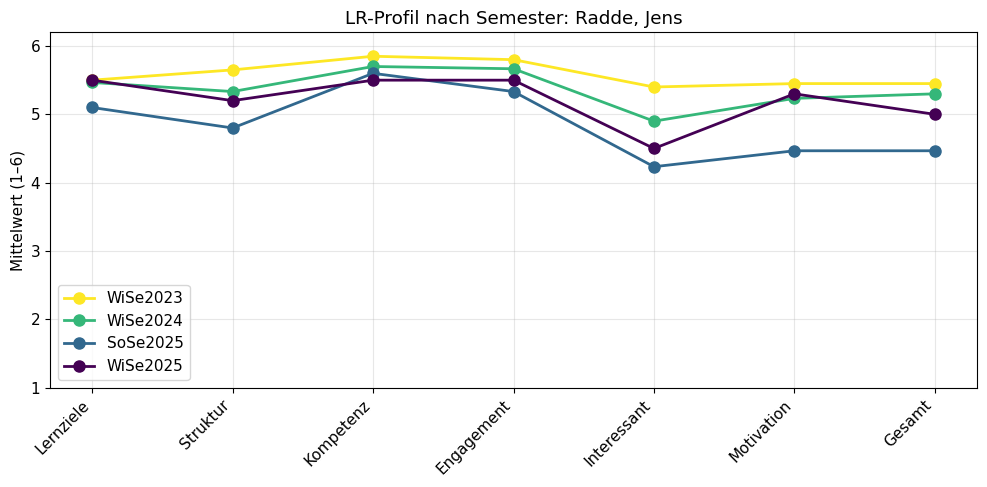

In [25]:
# --- Dozent hier eintragen ---
DOZENT = 'Radde, Jens'

plot_lecturer_trends(DOZENT)
plot_lecturer_profile(DOZENT)

## Freitext-Feedback pro Dozent

In [16]:
CATEGORY_LABELS = {
    'motivating_methods': 'Motivierende Lehrmethoden',
    'positive_feedback': 'Was gut gefallen hat / beibehalten',
    'improvement_suggestions': 'Verbesserungsvorschläge',
}


def show_feedback(lecturer_name, semester=None):
    """Freitext-Feedback für einen Dozenten anzeigen."""
    data = df_text[df_text['lecturer_name'] == lecturer_name]
    if semester:
        data = data[data['semester'] =='semester']

    if data.empty:
        print(f'Kein Freitext-Feedback für {lecturer_name}')
        return

    for cat_key, cat_label in CATEGORY_LABELS.items():
        cat_data = data[data['category'] == cat_key]
        if cat_data.empty:
            continue

        print(f'\n{"=" * 60}')
        print(f'  {cat_label} ({len(cat_data)} Antworten)')
        print(f'{"=" * 60}')

        for sem in semester_order:
            sem_data = cat_data[cat_data['semester'] == sem]
            if sem_data.empty:
                continue
            print(f'\n  [{sem}]')
            for _, row in sem_data.iterrows():
                course = str(row.get('course_title', ''))[:50]
                print(f'    ({course})')
                print(f'    → {row["response_text"]}')


semester_order = ['WiSe2023', 'SoSe2024', 'WiSe2024', 'SoSe2025', 'WiSe2025']

In [24]:
# --- Dozent hier eintragen ---
show_feedback('Radde, Jens')


  Motivierende Lehrmethoden (54 Antworten)

  [WiSe2023]
    (BWL-M06-RW-HS-F01 Handels- und Steuerbilanzen/Steu)
    → alt. Klausurformat
    (BWL-M06-RW-HS-F01 Handels- und Steuerbilanzen/Steu)
    → Die Übungsaufgaben sowie die Präsentation
    (BWL-M06-RW-HS-F01 Handels- und Steuerbilanzen/Steu)
    → Durch das ausführliche Auseinandersetzen in Zusammenhang mit der Vorbereitung für den Vortrag
    (BWL-M06-RW-HS-F01 Handels- und Steuerbilanzen/Steu)
    → Durch die asynchrone Lehre konnte ich die Handelsbilanzen stressfreier studieren. An Wochen wo die Organisation des Stundenplans eher schwierig ist ist das Goldwert.
    (BWL-M06-RW-HS-F01 Handels- und Steuerbilanzen/Steu)
    → Durch die Gruppenaufgaben und die Übungen.
    (BWL-M06-RW-HS-F01 Handels- und Steuerbilanzen/Steu)
    → Gerade die Übubgsaufgaben und die Präsentation motivieren zur eigenen Mitarbeit und bringt einen hohen Praxisbezug
    (BWL-M06-RW-HS-F01 Handels- und Steuerbilanzen/Steu)
    → Gruppenarbeit
    (BWL

## Dozenten-Vergleich: Gesamtbewertung (LR07)

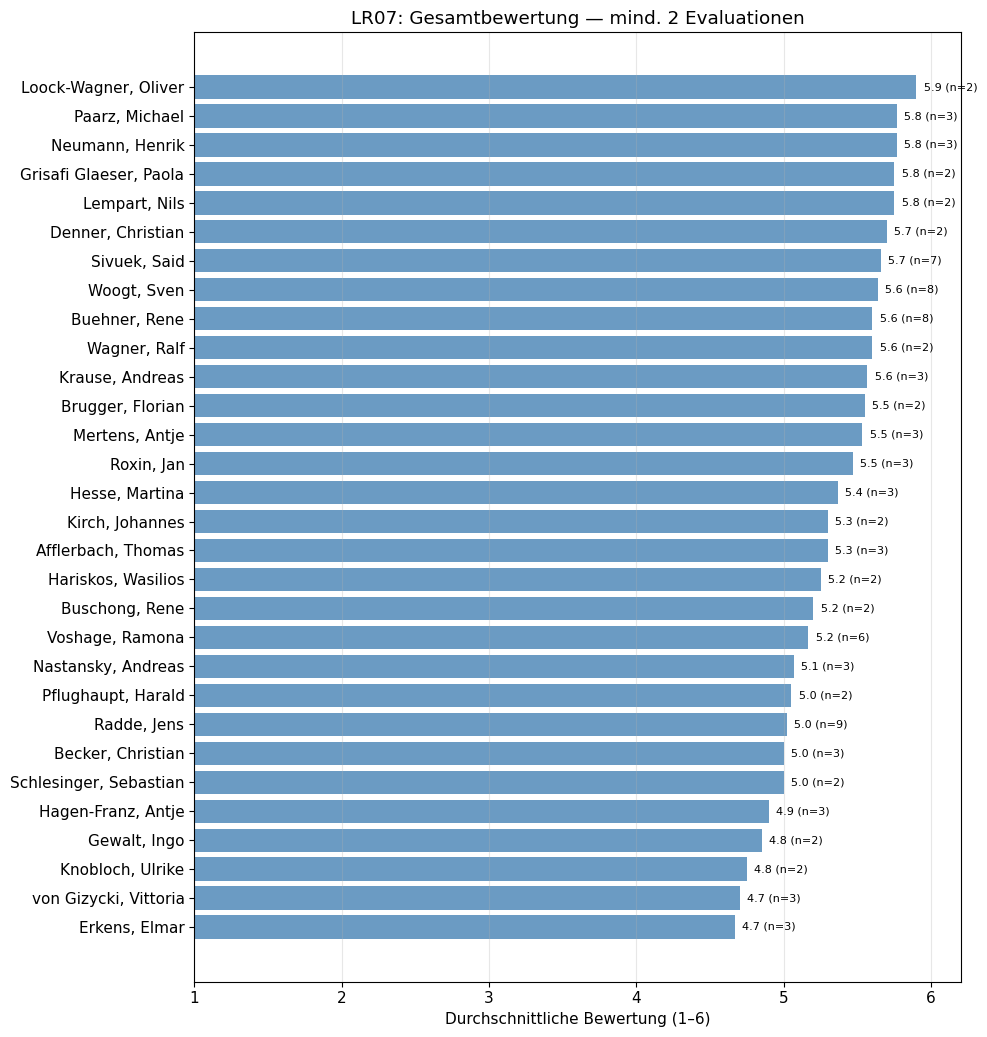

In [18]:
def plot_comparison(question='lr07', min_evaluations=2, top_n=25):
    """Balkendiagramm: Dozenten-Vergleich für eine Frage."""
    stats = df.groupby('lecturer_name')[question].agg(['mean', 'count', 'std']).dropna()
    stats = stats[stats['count'] >= min_evaluations].sort_values('mean', ascending=True).tail(top_n)

    fig, ax = plt.subplots(figsize=(10, max(6, len(stats) * 0.35)))
    bars = ax.barh(stats.index, stats['mean'], color='steelblue', alpha=0.8)
    ax.set_xlabel('Durchschnittliche Bewertung (1–6)')
    ax.set_xlim(1, 6.2)

    for i, (name, row) in enumerate(stats.iterrows()):
        ax.text(row['mean'] + 0.05, i, f'{row["mean"]:.1f} (n={int(row["count"])})', va='center', fontsize=8)

    label = LR_COLS.get(question, question)
    ax.set_title(f'{label} — mind. {min_evaluations} Evaluationen')
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()


plot_comparison('lr07', min_evaluations=2, top_n=30)

## Durchschnitt pro Semester

In [19]:
lr_cols = [f'lr0{i}' for i in range(1, 8)]
semester_means = df.groupby('semester', observed=True)[lr_cols].mean().round(2)
semester_means.columns = [LR_COLS[c] for c in lr_cols]
semester_means

,LR01: Lernziele klar definiert,LR02: Gut strukturiert,LR03: Fachliche Kompetenz,LR04: Engagement,LR05: Interessant gestaltet,LR06: Motiviert zur Beteiligung,LR07: Gesamtbewertung
semester,,,,,,,
WiSe2023,5.02,5.11,5.52,5.45,4.73,4.93,4.79
SoSe2024,5.09,5.01,5.46,5.40,4.67,4.80,4.76
WiSe2024,4.95,4.99,5.49,5.44,4.66,4.85,4.77
SoSe2025,5.16,5.13,5.69,5.63,4.83,5.07,4.88
WiSe2025,5.13,4.98,5.52,5.53,4.88,4.98,4.90
